# compression analyse

In [1]:
import os
import time
import pandas as pd
from tqdm import tqdm

import gzip
import bz2
import lzma
import brotli
import zstandard as zstd

import matplotlib.pyplot as plt
import numpy as np

from tex_tool import TexExtractor

## configuration

In [2]:
BASE_DIR = "files"
INPUT_XLSX = f"{BASE_DIR}/arxiv_tex_dataset.xlsx"
TAR_DIR = f"{BASE_DIR}/downloads/"
OUTPUT_XLSX = f"{BASE_DIR}/compression.xlsx"

plt.rcParams.update({
    "font.size": 8,
    "axes.labelsize": 8,
    "legend.fontsize": 7,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7
})

## compression algarithem

In [3]:
def compress_gzip(data: bytes):
    start = time.perf_counter()
    compressed = gzip.compress(data, compresslevel=9)
    comp_time = time.perf_counter() - start

    start = time.perf_counter()
    gzip.decompress(compressed)
    decomp_time = time.perf_counter() - start

    return len(compressed), comp_time, decomp_time


def compress_bz2(data: bytes):
    start = time.perf_counter()
    compressed = bz2.compress(data, compresslevel=9)
    comp_time = time.perf_counter() - start

    start = time.perf_counter()
    bz2.decompress(compressed)
    decomp_time = time.perf_counter() - start

    return len(compressed), comp_time, decomp_time


def compress_lzma(data: bytes):
    start = time.perf_counter()
    compressed = lzma.compress(data, preset=9)
    comp_time = time.perf_counter() - start

    start = time.perf_counter()
    lzma.decompress(compressed)
    decomp_time = time.perf_counter() - start

    return len(compressed), comp_time, decomp_time


def compress_brotli(data: bytes):
    start = time.perf_counter()
    compressed = brotli.compress(data, quality=11)
    comp_time = time.perf_counter() - start

    start = time.perf_counter()
    brotli.decompress(compressed)
    decomp_time = time.perf_counter() - start

    return len(compressed), comp_time, decomp_time


def compress_zstd(data: bytes):
    cctx = zstd.ZstdCompressor(level=19)
    dctx = zstd.ZstdDecompressor()

    start = time.perf_counter()
    compressed = cctx.compress(data)
    comp_time = time.perf_counter() - start

    start = time.perf_counter()
    dctx.decompress(compressed)
    decomp_time = time.perf_counter() - start

    return len(compressed), comp_time, decomp_time


ALGORITHMS = {
    "gzip": compress_gzip,
    "bz2": compress_bz2,
    "lzma": compress_lzma,
    "brotli": compress_brotli,
    "zstd": compress_zstd,
}

## main

In [4]:
def main():
    df = pd.read_excel(INPUT_XLSX)

    results = []
    total = len(df)
    pbar = tqdm(df.iterrows(), total=total, desc="Processing papers")
    for idx, row in pbar:
        arxiv_id = row["id"]
        tar_path = os.path.join(TAR_DIR, f"{arxiv_id}.tar.gz")

        pbar.set_postfix({
            "index": f"{idx+1}/{total}",
            "id": arxiv_id
        })

        if not os.path.exists(tar_path):
            continue

        # tex_raw = extract_tex_from_tar(tar_path)
        extractor = TexExtractor(tar_path)
        tex_clean = extractor.get_merged_tex()
        if not tex_clean:
            continue

        # tex_clean = remove_latex_comments(tex_raw)

        data_bytes = tex_clean.encode("utf-8", errors="ignore")
        original_size = len(data_bytes)

        if original_size == 0:
            continue

        for algo_name, func in ALGORITHMS.items():
            try:
                comp_size, comp_time, decomp_time = func(data_bytes)

                results.append({
                    "id": arxiv_id,
                    "title": row['title'],
                    "size": row["tex_size_clean"],
                    "algorithm": algo_name,
                    "original_size": original_size,
                    "compressed_size": comp_size,
                    "compression_time": comp_time,
                    "decompression_time": decomp_time,
                })
            except Exception as e:
                print(f"[ERROR] {arxiv_id} - {algo_name}: {e}")

    result_df = pd.DataFrame(results)
    result_df.to_excel(OUTPUT_XLSX, index=False)

    print("Done! Results saved to:", OUTPUT_XLSX)

In [5]:
main()

Processing papers: 100%|██████████| 472/472 [01:18<00:00,  6.04it/s, index=472/472, id=2603.02075v1]


Done! Results saved to: files/compression.xlsx


# comprssion ratio

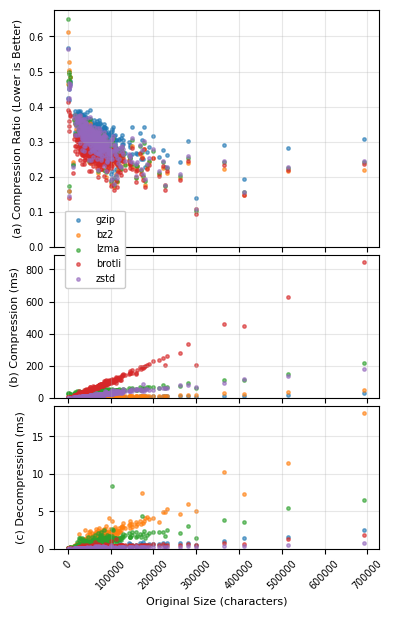

In [6]:

def combined_plots():
    df = pd.read_excel(OUTPUT_XLSX)
    df["compression_ratio"] = df["compressed_size"]/df["original_size"]

    # 获取唯一的算法列表用于图例
    algorithms = df["algorithm"].unique()
    
    # 创建图形，使用GridSpec控制子图大小比例
    fig = plt.figure(figsize=(4.2, 7))  # 宽度8，高度10
    gs = fig.add_gridspec(3, 1, height_ratios=[5, 3, 3], hspace=0.05)  # 第一个图高度是后面的2倍
    
    # 创建三个子图，共享x轴
    ax1 = fig.add_subplot(gs[0])  # 压缩比图（高度2）
    ax2 = fig.add_subplot(gs[1], sharex=ax1)  # 压缩时间图（高度1）
    ax3 = fig.add_subplot(gs[2], sharex=ax1)  # 解压时间图（高度1）
    
    # 存储所有图例句柄
    legend_handles = {}
    
    # 1. 压缩比图（上）
    for algo in algorithms:
        subset = df[df["algorithm"] == algo]
        scatter = ax1.scatter(subset["original_size"], subset["compression_ratio"], 
                              label=algo, s=6, alpha=0.6)
        legend_handles[algo] = scatter
    
    ax1.set_ylabel("(a) Compression Ratio (Lower is Better)")
    ax1.tick_params(axis='x', labelbottom=False)  # 隐藏x轴标签
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim(bottom=0)  # 从0开始
    
    # 2. 压缩时间图（中）
    for algo in algorithms:
        subset = df[df["algorithm"] == algo]
        ax2.scatter(subset["original_size"], subset["compression_time"]*1000, 
                    label=algo, s=6, alpha=0.6)
    
    ax2.set_ylabel("(b) Compression (ms)")
    ax2.tick_params(axis='x', labelbottom=False)  # 隐藏x轴标签
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim(bottom=0)
    
    # 3. 解压时间图（下）
    for algo in algorithms:
        subset = df[df["algorithm"] == algo]
        ax3.scatter(subset["original_size"], subset["decompression_time"]*1000, 
                    label=algo, s=6, alpha=0.6)
    
    ax3.set_xlabel("Original Size (characters)")
    ax3.set_ylabel("(c) Decompression (ms)")
    ax3.grid(True, alpha=0.3)
    ax3.set_ylim(bottom=0)
    
    # 设置x轴刻度旋转
    for ax in [ax1, ax2, ax3]:
        ax.tick_params(axis='x', rotation=45)
    
    legend = fig.legend(handles=list(legend_handles.values()), labels=algorithms,
                       loc='upper left', bbox_to_anchor=(0.14, 0.60), framealpha=1)

    plt.show()

combined_plots()

In [7]:
def noise():
    df = pd.read_excel(OUTPUT_XLSX)
    df["compression_ratio"] = df["compressed_size"]/df["original_size"]
    min_idx = df["compression_ratio"].idxmin()
    min_rows = df.loc[min_idx]
    return min_rows
noise()

id                                                         2603.29367v1
title                 Exploration of Energy and Throughput Tradeoffs...
size                                                             299183
algorithm                                                        brotli
original_size                                                    299183
compressed_size                                                   28103
compression_time                                               0.201074
decompression_time                                             0.000513
compression_ratio                                              0.093932
Name: 908, dtype: object

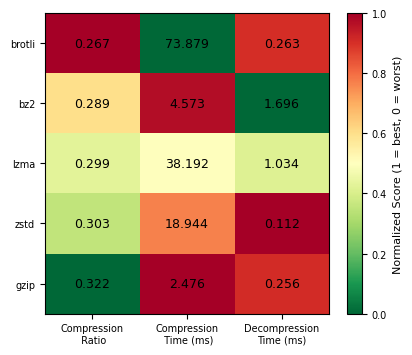

In [8]:
def mean_ratio_heatmap():
    df = pd.read_excel(OUTPUT_XLSX)
    df["compression_ratio"] = df["compressed_size"]/df["original_size"]
    df = df[df["id"] != '2602.17318v1']
    df["compression_time"] = df["compression_time"] * 1000
    df["decompression_time"] = df["decompression_time"] * 1000

    summary = df.groupby("algorithm").agg({
        "compression_ratio": "mean",
        "compression_time": "mean",
        "decompression_time": "mean"
    }).reset_index()
    summary = summary.sort_values("compression_ratio")

    # 准备数据
    algorithms = summary["algorithm"].tolist()
    metrics = ['compression_ratio', 'compression_time', 'decompression_time']
    metric_labels = ['Compression\n Ratio', 'Compression\n Time (ms)', 'Decompression\nTime (ms)']
    
    data = summary[metrics].values  # 转置前的原始数据
    
    # ======================
    # 关键：对每个指标进行归一化（Min-Max归一化）
    # ======================
    data_normalized = np.zeros_like(data)
    for i in range(len(metrics)):
        col = data[:, i]  # 现在是按列取指标
        min_val = col.min()
        max_val = col.max()
        if max_val > min_val:
            # 越小越好，所以用 1 - (x - min)/(max - min)
            data_normalized[:, i] = 1 - (col - min_val) / (max_val - min_val)
        else:
            data_normalized[:, i] = 0.5

    fig, ax = plt.subplots(figsize=(4.2, 3.6))
    
    # 使用归一化后的数据绘制热力图（不需要转置）
    im = ax.imshow(data_normalized, cmap='RdYlGn_r', aspect='auto', vmin=0, vmax=1)
    
    # 设置标签（算法在Y轴，指标在X轴）
    ax.set_yticks(np.arange(len(algorithms)))
    ax.set_yticklabels(algorithms)
    ax.set_xticks(np.arange(len(metrics)))
    ax.set_xticklabels(metric_labels)
    
    # 添加原始数值标签
    for i in range(len(algorithms)):  # 行：算法
        for j in range(len(metrics)):  # 列：指标
            original_value = data[i, j]
            if metrics[j] == 'compression_ratio':
                ax.text(j, i, f'{original_value:.3f}',
                       ha="center", va="center", color="black", fontsize=9)
            else:
                ax.text(j, i, f'{original_value:.3f}',
                       ha="center", va="center", color="black", fontsize=9)
    
    # ax.set_title("Performance Metrics Heatmap (Normalized by Metric)\n(darker = better relative to other algorithms)", fontsize=11)

    
    # 添加颜色条
    cbar = plt.colorbar(im, ax=ax, label='Normalized Score (1 = best, 0 = worst)')
    
    plt.tight_layout()
    plt.show()
mean_ratio_heatmap()

In [9]:
def summary_table():
    df = pd.read_excel(OUTPUT_XLSX)
    df["compression_ratio"] = df["compressed_size"]/df["original_size"]
    df =  df[df["id"] != '2602.17318v1']

    mean = df.groupby("algorithm").agg({
        "compression_ratio": "mean",
        "compression_time": "mean",
        "decompression_time": "mean"
    }).reset_index()
    median = df.groupby("algorithm").agg({
        "compression_ratio": "median",
        "compression_time": "median",
        "decompression_time": "median"
    }).reset_index()
    std = df.groupby("algorithm").agg({
        "compression_ratio": "std"
    }).reset_index()
    df = pd.concat([
        mean,
        median[['compression_ratio', 'compression_time', 'decompression_time']].rename(
            columns={
                'compression_ratio':'cr_median',
                'compression_time':'ct_median',
                'decompression_time':'dt_median'
                }
            ),
        std[['compression_ratio']].rename(columns={'compression_ratio':'cr_std'})
        ], axis=1)
    # df["compression_time"] = df["compression_time"] * 1000
    return df
summary_table()[['algorithm','compression_ratio','cr_median','cr_std',	'compression_time','ct_median',	'decompression_time','dt_median']]

,algorithm,compression_ratio,cr_median,cr_std,compression_time,ct_median,decompression_time,dt_median
0,brotli,0.267359,0.269346,0.032238,0.073879,0.063170,0.000263,0.000240
1,bz2,0.289223,0.288866,0.046458,0.004573,0.004002,0.001696,0.001483
2,gzip,0.321741,0.323573,0.038709,0.002476,0.002062,0.000256,0.000219
3,lzma,0.298509,0.300095,0.045549,0.038192,0.035916,0.001034,0.000914
4,zstd,0.302532,0.305215,0.042540,0.018944,0.015422,0.000112,0.000101
